# LS-DeepONet for A-KIT Synthetic DVL Beams to Cartesian Velocity

This notebook predicts **Cartesian DVL velocity** from raw 4-beam DVL measurements generated in the A-KIT folder structure.

Expected per trajectory:

| File | Meaning |
|---|---|
| `A-KIT/Data/Trajectory1/DVL_beams_traj_1.npy` | `(N,5)` = `[time, beam1, beam2, beam3, beam4]`, or `(N,4)` = beams only |
| `A-KIT/Data/Trajectory1/DVL_trajectory1.csv` | GT Cartesian DVL velocity columns |

The corrected pipeline is:

```text
A-KIT trajectories
    -> load beam + Cartesian velocity pairs
    -> trajectory-aware train/val/test split
    -> windowed 4-beam history
    -> DNN, CNN, BeamsNetV2, and LS-DeepONet velocity prediction
    -> compare against classical least-squares velocity
```

Important fixes in this version:

- Removes one-off debug cells that could fail with undefined variables.
- Prevents history windows from crossing trajectory boundaries.
- Splits by whole trajectories by default, which gives a cleaner generalization test.
- Removes the shuffled-batch smoothness loss because adjacent rows in a shuffled batch are not adjacent in time.
- Reports metrics for train, validation, test, and full aligned data.


This updated version adds fair DVL-only neural baselines: **DNN**, **CNN**, **BeamsNetV2**, and **LS-DeepONet**. BeamsNetV2 uses the current 4-beam DVL sample plus the windowed 4-beam DVL history, so it remains a DVL-only baseline.


In [1]:
# ============================================================
# 0. Imports, setup, and reproducibility
# ============================================================

import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.benchmark = torch.cuda.is_available()

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print("Using device:", DEVICE)

SAVE_DIR = Path("ls_deeponet_dvl_velocity_results")
FIG_DIR = SAVE_DIR / "figures"
CKPT_DIR = SAVE_DIR / "checkpoints"
DATA_DIR = SAVE_DIR / "arrays"
for directory in (FIG_DIR, CKPT_DIR, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Results folder:", SAVE_DIR.resolve())


Using device: cuda
Results folder: /home/asahoo/DVL/ls_deeponet_dvl_velocity_results


In [2]:
# ============================================================
# 1. Load A-KIT generated DVL beams and Cartesian velocity GT
# ============================================================
# Expected per trajectory:
#   A-KIT/Data/Trajectory1/DVL_beams_traj_1.npy
#   A-KIT/Data/Trajectory1/DVL_trajectory1.csv
#
# DVL_beams_traj_*.npy shape:
#   (N,5) = [time, beam1, beam2, beam3, beam4]
#   or (N,4) = [beam1, beam2, beam3, beam4]
#
# DVL_trajectory*.csv columns:
#   Time [s], DVL X [m/s], DVL Y [m/s], DVL Z [m/s]
# ============================================================

import re
import pandas as pd

DATA_ROOT = Path("A-KIT/Data")
ALPHA_DEG = 20.0

# Prefer splitting by whole trajectories to test generalization.
# Leave these as None to split trajectory IDs automatically.
# TRAIN_TRAJECTORIES = None     # example: [1, 2, 3, 4, 5, 6, 7, 8]
# VAL_TRAJECTORIES = None       # example: [9, 10]
# TEST_TRAJECTORIES = None      # example: [11, 12, 13]


TRAIN_TRAJECTORIES =[1, 6, 7, 8, 9, 10, 11, 12, 13]  #[4, 5, 6, 7, 8, 9, 10, 11, 12]  #[1, 2, 3, 4, 5, 6, 7, 8, 9]                 
VAL_TRAJECTORIES = [2,3] #[1,13]#
TEST_TRAJECTORIES = [4,5]#[4,5] 


REQUIRED_VELOCITY_COLUMNS = ["DVL X [m/s]", "DVL Y [m/s]", "DVL Z [m/s]"]


def build_dvl_H(alpha_deg=20.0):
    """Build the 4x3 DVL beam geometry matrix used by the A-KIT beam generator."""
    alpha = np.deg2rad(alpha_deg)
    H = []
    for i in range(4):
        psi = np.deg2rad(45 + i * 90)
        H.append([
            np.cos(psi) * np.sin(alpha),
            np.sin(psi) * np.sin(alpha),
            np.cos(alpha),
        ])
    return np.asarray(H, dtype=np.float32)


def natural_traj_number(path):
    """Extract trajectory number from Trajectory12 or DVL_beams_traj_12.npy."""
    s = str(path)
    m = re.search(r"Trajectory(\d+)", s)
    if m:
        return int(m.group(1))
    m = re.search(r"traj_(\d+)", s)
    if m:
        return int(m.group(1))
    return 10**9


def load_akit_beam_velocity_data(data_root=DATA_ROOT, alpha_deg=20.0):
    data_root = Path(data_root)
    H_np = build_dvl_H(alpha_deg=alpha_deg)
    traj_dirs = sorted(data_root.glob("Trajectory*"), key=natural_traj_number)
    if len(traj_dirs) == 0:
        raise FileNotFoundError(f"No Trajectory* folders found inside: {data_root.resolve()}")

    all_t, all_beams, all_vel, all_traj_id, summaries = [], [], [], [], []
    global_time_offset = 0.0

    for traj_dir in traj_dirs:
        traj_num = natural_traj_number(traj_dir)
        beam_path = traj_dir / f"DVL_beams_traj_{traj_num}.npy"
        csv_path = traj_dir / f"DVL_trajectory{traj_num}.csv"

        if not beam_path.exists() or not csv_path.exists():
            missing = [path.name for path in (beam_path, csv_path) if not path.exists()]
            print(f"Skipping Trajectory{traj_num}: missing {missing}")
            continue

        beams_npy = np.load(beam_path).astype(np.float32)
        df = pd.read_csv(csv_path)
        missing_cols = [col for col in REQUIRED_VELOCITY_COLUMNS if col not in df.columns]
        if missing_cols:
            raise ValueError(f"{csv_path} missing required columns: {missing_cols}")

        if beams_npy.ndim != 2 or beams_npy.shape[1] not in (4, 5):
            raise ValueError(f"{beam_path} must have shape (N,4) or (N,5), got {beams_npy.shape}")

        if beams_npy.shape[1] == 5:
            t_local = beams_npy[:, 0:1]
            beams = beams_npy[:, 1:5]
        else:
            beams = beams_npy[:, 0:4]
            if "Time [s]" in df.columns:
                t_local = df["Time [s]"].to_numpy(dtype=np.float32).reshape(-1, 1)
            else:
                t_local = np.arange(len(beams), dtype=np.float32).reshape(-1, 1)

        vel = df[REQUIRED_VELOCITY_COLUMNS].to_numpy(dtype=np.float32)
        N = min(len(t_local), len(beams), len(vel))
        if N < 2:
            print(f"Skipping Trajectory{traj_num}: fewer than two aligned samples")
            continue

        t_local = t_local[:N]
        beams = beams[:N]
        vel = vel[:N]

        if not np.isfinite(t_local).all() or not np.isfinite(beams).all() or not np.isfinite(vel).all():
            raise ValueError(f"Non-finite values found in Trajectory{traj_num}")

        dt = np.diff(t_local[:, 0])
        if np.any(dt <= 0):
            raise ValueError(f"Local time must be strictly increasing in Trajectory{traj_num}")
        dt_est = float(np.median(dt))

        # Make one global time axis for plotting while keeping trajectory IDs for safe windowing.
        t_shifted = t_local - float(t_local[0, 0]) + global_time_offset
        global_time_offset = float(t_shifted[-1, 0] + dt_est)

        all_t.append(t_shifted.astype(np.float32))
        all_beams.append(beams.astype(np.float32))
        all_vel.append(vel.astype(np.float32))
        all_traj_id.append(np.full((N, 1), traj_num, dtype=np.int64))
        summaries.append((traj_num, N, dt_est))
        print(f"Loaded Trajectory{traj_num}: N={N}, dt~{dt_est:.4g}s")

    if len(all_t) == 0:
        raise FileNotFoundError("No valid trajectory pairs were loaded. Check the A-KIT output paths.")

    t = np.vstack(all_t).astype(np.float32)
    dvl_beams = np.vstack(all_beams).astype(np.float32)
    dvl_cart_gt = np.vstack(all_vel).astype(np.float32)
    traj_id = np.vstack(all_traj_id).astype(np.int64)
    return t, dvl_beams, dvl_cart_gt, H_np, traj_id, summaries


def validate_arrays(t, dvl_beams, dvl_cart_gt, H_np, traj_id):
    t = np.asarray(t, dtype=np.float32)
    if t.ndim == 1:
        t = t[:, None]
    dvl_beams = np.asarray(dvl_beams, dtype=np.float32)
    dvl_cart_gt = np.asarray(dvl_cart_gt, dtype=np.float32)
    H_np = np.asarray(H_np, dtype=np.float32)
    traj_id = np.asarray(traj_id, dtype=np.int64)
    if traj_id.ndim == 1:
        traj_id = traj_id[:, None]

    if t.ndim != 2 or t.shape[1] != 1:
        raise ValueError(f"time must have shape (N,) or (N,1); got {t.shape}")
    if dvl_beams.ndim != 2 or dvl_beams.shape[1] != 4:
        raise ValueError(f"dvl_beams must have shape (N,4); got {dvl_beams.shape}")
    if dvl_cart_gt.ndim != 2 or dvl_cart_gt.shape[1] != 3:
        raise ValueError(f"dvl_cartesian_gt must have shape (N,3); got {dvl_cart_gt.shape}")
    if H_np.shape != (4, 3):
        raise ValueError(f"H_dvl must have shape (4,3); got {H_np.shape}")
    if not (len(t) == len(dvl_beams) == len(dvl_cart_gt) == len(traj_id)):
        raise ValueError("N mismatch between time, beams, Cartesian velocity, and trajectory IDs")
    if np.any(np.diff(t[:, 0]) <= 0):
        raise ValueError("global time values must be strictly increasing")

    arrays = {"time": t, "dvl_beams": dvl_beams, "dvl_cartesian_gt": dvl_cart_gt, "H": H_np}
    bad = [name for name, arr in arrays.items() if not np.isfinite(arr).all()]
    if bad:
        raise ValueError(f"Non-finite values found in: {bad}")

    return t, dvl_beams, dvl_cart_gt, H_np, traj_id


t, dvl_beams, dvl_cart_gt, H_np, traj_id, traj_summaries = load_akit_beam_velocity_data(DATA_ROOT, ALPHA_DEG)
t, dvl_beams, dvl_cart_gt, H_np, traj_id = validate_arrays(t, dvl_beams, dvl_cart_gt, H_np, traj_id)
VEL_DIM = dvl_cart_gt.shape[1]

DATA_DIR.mkdir(parents=True, exist_ok=True)
np.save(DATA_DIR / "akit_time_global.npy", t)
np.save(DATA_DIR / "akit_dvl_beams.npy", dvl_beams)
np.save(DATA_DIR / "akit_dvl_cartesian_gt.npy", dvl_cart_gt)
np.save(DATA_DIR / "akit_H_dvl.npy", H_np)
np.save(DATA_DIR / "akit_traj_id.npy", traj_id)

print("\nFinal connected dataset")
print("time shape            :", t.shape)
print("dvl_beams shape       :", dvl_beams.shape)
print("dvl_cartesian_gt shape:", dvl_cart_gt.shape)
print("H shape               :", H_np.shape)
print("VEL_DIM               :", VEL_DIM)
print("Trajectory IDs        :", np.unique(traj_id[:, 0]).astype(int))


Loaded Trajectory1: N=400, dt~1.003s
Loaded Trajectory2: N=400, dt~1.003s
Loaded Trajectory3: N=400, dt~1.003s
Loaded Trajectory4: N=400, dt~1.003s
Loaded Trajectory5: N=400, dt~1.003s
Loaded Trajectory6: N=400, dt~1.003s
Loaded Trajectory7: N=400, dt~1.003s
Loaded Trajectory8: N=400, dt~1.003s
Loaded Trajectory9: N=400, dt~1.003s
Loaded Trajectory10: N=400, dt~1.003s
Loaded Trajectory11: N=400, dt~1.003s
Loaded Trajectory12: N=400, dt~1.003s
Loaded Trajectory13: N=400, dt~1.003s

Final connected dataset
time shape            : (5200, 1)
dvl_beams shape       : (5200, 4)
dvl_cartesian_gt shape: (5200, 3)
H shape               : (4, 3)
VEL_DIM               : 3
Trajectory IDs        : [ 1  2  3  4  5  6  7  8  9 10 11 12 13]


In [3]:
# ============================================================
# 2. Normalization, trajectory-aware split, and LS baseline
# ============================================================

WINDOW = 2 #10: 0.133 #5: 0.092
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15


def safe_std(x, axis=0, eps=1e-8):
    return np.maximum(np.std(x, axis=axis, keepdims=True), eps).astype(np.float32)


def split_trajectory_ids(unique_ids, train_ratio=0.70, val_ratio=0.15):
    unique_ids = np.asarray(sorted(unique_ids), dtype=np.int64)
    if TRAIN_TRAJECTORIES is not None or VAL_TRAJECTORIES is not None or TEST_TRAJECTORIES is not None:
        train_ids = np.asarray([] if TRAIN_TRAJECTORIES is None else TRAIN_TRAJECTORIES, dtype=np.int64)
        val_ids = np.asarray([] if VAL_TRAJECTORIES is None else VAL_TRAJECTORIES, dtype=np.int64)
        test_ids = np.asarray([] if TEST_TRAJECTORIES is None else TEST_TRAJECTORIES, dtype=np.int64)
    else:
        n_total = len(unique_ids)
        if n_total < 3:
            raise ValueError("Need at least three trajectories for trajectory-level train/val/test split")
        n_train = max(1, int(round(n_total * train_ratio)))
        n_val = max(1, int(round(n_total * val_ratio)))
        if n_train + n_val >= n_total:
            n_train = max(1, n_total - 2)
            n_val = 1
        train_ids = unique_ids[:n_train]
        val_ids = unique_ids[n_train:n_train + n_val]
        test_ids = unique_ids[n_train + n_val:]

    assigned = np.concatenate([train_ids, val_ids, test_ids])
    if len(assigned) != len(np.unique(assigned)):
        raise ValueError("Train/val/test trajectory lists overlap")
    missing = set(unique_ids.tolist()) - set(assigned.tolist())
    if missing:
        print("Unused trajectory IDs:", sorted(missing))
    if len(train_ids) == 0 or len(val_ids) == 0 or len(test_ids) == 0:
        raise ValueError("Train, validation, and test trajectory sets must all be non-empty")
    return train_ids, val_ids, test_ids


def indices_for_trajectories(ids):
    ids = np.asarray(ids, dtype=np.int64)
    return np.flatnonzero(np.isin(traj_id[:, 0], ids))


def beams_to_cartesian_ls(beams, H, vel_dim):
    # Classical least-squares conversion from four beams to Cartesian velocity.
    v3 = beams @ np.linalg.pinv(H).T
    return v3[:, :vel_dim].astype(np.float32)


N = len(t)
unique_traj_ids = np.unique(traj_id[:, 0])
train_traj_ids, val_traj_ids, test_traj_ids = split_trajectory_ids(unique_traj_ids, TRAIN_RATIO, VAL_RATIO)
idx_train = indices_for_trajectories(train_traj_ids)
idx_val = indices_for_trajectories(val_traj_ids)
idx_test = indices_for_trajectories(test_traj_ids)

dvl_cart_ls = beams_to_cartesian_ls(dvl_beams, H_np, VEL_DIM)

# Compute normalization statistics from training samples only.
t_mean = t[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
t_std = safe_std(t[idx_train], axis=0)
beam_mean = dvl_beams[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
beam_std = safe_std(dvl_beams[idx_train], axis=0)
vel_mean = dvl_cart_gt[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
vel_std = safe_std(dvl_cart_gt[idx_train], axis=0)

t_n = (t - t_mean) / t_std
beams_n = (dvl_beams - beam_mean) / beam_std
vel_gt_n = (dvl_cart_gt - vel_mean) / vel_std

print("Train trajectory IDs:", train_traj_ids)
print("Val trajectory IDs  :", val_traj_ids)
print("Test trajectory IDs :", test_traj_ids)
print("Train samples:", len(idx_train))
print("Val samples  :", len(idx_val))
print("Test samples :", len(idx_test))
print("Velocity mean:", vel_mean)
print("Velocity std :", vel_std)

ls_err = np.linalg.norm(dvl_cart_ls - dvl_cart_gt[:, :VEL_DIM], axis=1)
print("LS sanity RMSE [m/s]:", float(np.sqrt(np.mean(ls_err ** 2))))
print("LS sanity mean error [m/s]:", float(np.mean(ls_err)))


Train trajectory IDs: [ 1  6  7  8  9 10 11 12 13]
Val trajectory IDs  : [2 3]
Test trajectory IDs : [4 5]
Train samples: 3600
Val samples  : 800
Test samples : 800
Velocity mean: [[1.9608576e+00 8.1083912e-04 1.2987200e-03]]
Velocity std : [[0.43833315 0.2987743  0.07166067]]
LS sanity RMSE [m/s]: 0.1248529851436615
LS sanity mean error [m/s]: 0.1118013858795166


In [4]:
# ============================================================
# 3. Dataset
# ============================================================

class DVLCartesianVelocityDataset(Dataset):
    def __init__(self, indices, window):
        self.window = int(window)
        indices = np.asarray(indices, dtype=np.int64)

        valid = []
        for i in indices:
            s = i - self.window + 1
            if s < 0:
                continue
            # Do not allow a history window to cross trajectory boundaries.
            if np.all(traj_id[s:i + 1, 0] == traj_id[i, 0]):
                valid.append(i)
        self.valid_indices = np.asarray(valid, dtype=np.int64)
        if len(self.valid_indices) == 0:
            raise ValueError("No valid samples for this split; reduce WINDOW or adjust the split")

        self.beams_n = torch.from_numpy(beams_n.astype(np.float32))
        self.t_n = torch.from_numpy(t_n.astype(np.float32))
        self.vel_gt_n = torch.from_numpy(vel_gt_n.astype(np.float32))
        self.beams_raw = torch.from_numpy(dvl_beams.astype(np.float32))
        self.t_raw = torch.from_numpy(t.astype(np.float32))
        self.traj_id = torch.from_numpy(traj_id.astype(np.int64))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, item):
        i = int(self.valid_indices[item])
        s = i - self.window + 1
        e = i + 1
        return {
            "branch": self.beams_n[s:e],
            "trunk": self.t_n[i],
            "vel": self.vel_gt_n[i],
            "beam_raw": self.beams_raw[i],
            "t_raw": self.t_raw[i],
            "traj_id": self.traj_id[i, 0],
            "index": torch.tensor(i, dtype=torch.long),
        }


BATCH_SIZE = 128
NUM_WORKERS = 0

generator = torch.Generator()
generator.manual_seed(SEED)
loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_ds = DVLCartesianVelocityDataset(idx_train, WINDOW)
val_ds = DVLCartesianVelocityDataset(idx_val, WINDOW)
test_ds = DVLCartesianVelocityDataset(idx_test, WINDOW)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator, **loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("Train dataset:", len(train_ds))
print("Val dataset  :", len(val_ds))
print("Test dataset :", len(test_ds))

sample = train_ds[0]
for key, value in sample.items():
    print(key, value.shape if hasattr(value, "shape") else value)


Train dataset: 3591
Val dataset  : 798
Test dataset : 798
branch torch.Size([2, 4])
trunk torch.Size([1])
vel torch.Size([3])
beam_raw torch.Size([4])
t_raw torch.Size([1])
traj_id torch.Size([])
index torch.Size([])


In [5]:
# ============================================================
# 4. Models: DNN baseline, CNN baseline, BeamsNetV2 baseline,
#    and LS-DeepONet
# ============================================================

FEATURE_DIM = 4
LATENT_DIM = 32


class DNNVelocity(nn.Module):
    def __init__(self, window, feat_dim, vel_dim=3):
        super().__init__()
        in_dim = window * feat_dim

        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, vel_dim)
        )

    def forward(self, branch, trunk=None):
        x = branch.reshape(branch.shape[0], -1)
        return self.net(x)


class CNNVelocity(nn.Module):
    def __init__(self, feat_dim=4, vel_dim=3):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(feat_dim, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, vel_dim)
        )

    def forward(self, branch, trunk=None):
        x = branch.transpose(1, 2)
        x = self.cnn(x).squeeze(-1)
        return self.head(x)


class BeamsNetV2Velocity(nn.Module):
    def __init__(self, window, feat_dim=4, vel_dim=3):
        super().__init__()

        self.conv_layer = nn.Sequential(
            nn.Conv1d(
                in_channels=window,
                out_channels=6,
                kernel_size=2,
                stride=1
            ),
            nn.Tanh(),
        )

        self.FC_ConvToFc = nn.Sequential(
            nn.Linear(18, 16),
            nn.ReLU(),

            nn.Linear(16, 2),
            nn.ReLU(),
        )

        self.FC_output = nn.Sequential(
            nn.Linear(6, vel_dim),
        )

        self.initialize_weights()

    def forward(self, branch, trunk=None):
        x = branch[:, -1, :]
        y = self.conv_layer(branch)
        y = torch.flatten(y, 1)
        y = self.FC_ConvToFc(y)

        z = torch.cat((x, y), dim=1)

        return self.FC_output(z)

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_uniform_(m.weight)

            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)


# ============================================================
# LS-DeepONet
#
# Branch : 4 -> 64 -> 128 -> 32
# Trunk  : 1 -> 64 -> 128 -> 32
# Fusion : 32 x 32 -> 32
# Head   : 32 -> 128 -> 64 -> 3
# ============================================================

class BranchCNN(nn.Module):
    def __init__(self, window, feat_dim=4, latent_dim=LATENT_DIM):
        super().__init__()

        self.net = nn.Sequential(

            nn.Conv1d(
                feat_dim,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.SiLU(),

            nn.Conv1d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.SiLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),

            nn.Linear(
                128,
                latent_dim
            ),
            nn.SiLU(),
        )

    def forward(self, branch):
        return self.net(
            branch.permute(0, 2, 1)
        )


class TrunkMLP(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(1, 64),
            nn.Tanh(),

            nn.Linear(64, 128),
            nn.Tanh(),

            nn.Linear(128, latent_dim),
            nn.Tanh(),
        )

    def forward(self, trunk):
        return self.net(trunk)


class LSDeepONetVelocity(nn.Module):
    def __init__(
        self,
        window,
        feat_dim=4,
        vel_dim=3,
        latent_dim=LATENT_DIM
    ):
        super().__init__()

        self.branch = BranchCNN(
            window,
            feat_dim=feat_dim,
            latent_dim=latent_dim
        )

        self.trunk = TrunkMLP(
            latent_dim=latent_dim
        )

        self.head = nn.Sequential(

            nn.LayerNorm(latent_dim),

            nn.Linear(latent_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.05),

            nn.Linear(128, 64),
            nn.SiLU(),

            nn.Linear(64, vel_dim),
        )

    def forward(self, branch, trunk):

        z_branch = self.branch(branch)
        z_trunk = self.trunk(trunk)

        # DeepONet element-wise fusion
        z = z_branch * z_trunk

        return self.head(z)


# ============================================================
# Model factory
# ============================================================

def make_model(model_name):

    if model_name == "DNN":
        return DNNVelocity(
            WINDOW,
            FEATURE_DIM,
            VEL_DIM
        ).to(DEVICE)

    if model_name == "CNN":
        return CNNVelocity(
            FEATURE_DIM,
            VEL_DIM
        ).to(DEVICE)

    if model_name == "BeamsNetV2":
        return BeamsNetV2Velocity(
            WINDOW,
            FEATURE_DIM,
            VEL_DIM
        ).to(DEVICE)

    if model_name == "LS_DeepONet":
        return LSDeepONetVelocity(
            WINDOW,
            FEATURE_DIM,
            VEL_DIM,
            latent_dim=LATENT_DIM
        ).to(DEVICE)

    raise ValueError(
        f"Unknown model_name: {model_name}"
    )


MODEL_NAMES = [
    "DNN",
    "CNN",
    "BeamsNetV2",
    "LS_DeepONet"
]


# ============================================================
# Architecture and trainable parameter summary
# ============================================================

ARCHITECTURE_INFO = {

    "DNN":
        f"{WINDOW * FEATURE_DIM}-128-64-3",

    "CNN":
        "4-32-64 | Head: 64-32-3",

    "BeamsNetV2":
        f"Conv: {WINDOW}-6 | FC: 18-16-2 | Head: 6-3",

    "LS_DeepONet":
        "Branch: 4-64-128-32 | "
        "Trunk: 1-64-128-32 | "
        "Fusion: 32x32->32 | "
        "Head: 32-128-64-3"
}


print("\n" + "=" * 95)
print("MODEL ARCHITECTURE AND TRAINABLE PARAMETERS")
print("=" * 95)

for name in MODEL_NAMES:

    tmp_model = make_model(name)

    n_params = sum(
        p.numel()
        for p in tmp_model.parameters()
        if p.requires_grad
    )

    print(f"\n{name}")
    print(f"Architecture : {ARCHITECTURE_INFO[name]}")
    print(f"Parameters   : {n_params:,}")

    del tmp_model

print("\n" + "=" * 95)

In [7]:
model = make_model("LS_DeepONet")

print(model.branch)
print(model.trunk)
print(model.head)

print(
    "Parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

BranchCNN(
  (net): Sequential(
    (0): Conv1d(4, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): SiLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): SiLU()
    (4): AdaptiveAvgPool1d(output_size=1)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=128, out_features=32, bias=True)
    (7): SiLU()
  )
)
TrunkMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=32, bias=True)
    (5): Tanh()
  )
)
Sequential(
  (0): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (1): Linear(in_features=32, out_features=128, bias=True)
  (2): SiLU()
  (3): Dropout(p=0.05, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): SiLU()
  (6): Linear(in_features=64, out_features=3, bias=True)
)
Parameters: 54979


In [8]:
# ============================================================
# 5. Loss functions
# ============================================================

vel_mean_t = torch.as_tensor(vel_mean, dtype=torch.float32, device=DEVICE)
vel_std_t = torch.as_tensor(vel_std, dtype=torch.float32, device=DEVICE)
H_t = torch.as_tensor(H_np, dtype=torch.float32, device=DEVICE)


def denorm_vel(vel_hat_n):
    return vel_hat_n * vel_std_t + vel_mean_t


def velocity_supervised_loss(vel_hat_n, vel_gt_n_batch):
    return torch.mean((vel_hat_n - vel_gt_n_batch) ** 2)


def beam_consistency_loss(vel_hat_n, beam_raw):
    # Enforces H @ v_cartesian ~= raw beams.
    vel_hat = denorm_vel(vel_hat_n)
    vel_3d = vel_hat[:, :3]
    beam_pred = vel_3d @ H_t.T
    return torch.mean((beam_pred - beam_raw) ** 2)


In [9]:
# ============================================================
# 6. Training setup for all neural baselines
# ============================================================

EPOCHS = 50
LR = 1e-4
PATIENCE = 20
MIN_DELTA = 1e-6

# DNN, CNN, and BeamsNetV2 use only supervised velocity loss.
# LS-DeepONet uses supervised velocity loss + beam consistency loss.
LAMBDA_VEL = 1.0
LAMBDA_BEAM = 0.10

TRAINING_CONFIG = {
    "DNN": {
        "use_beam_loss": False,
        "checkpoint": CKPT_DIR / "best_dnn_velocity.pt",
    },
    "CNN": {
        "use_beam_loss": False,
        "checkpoint": CKPT_DIR / "best_cnn_velocity.pt",
    },
    "BeamsNetV2": {
        "use_beam_loss": False,
        "checkpoint": CKPT_DIR / "best_beamsnetv2_velocity.pt",
    },
    "LS_DeepONet": {
        "use_beam_loss": True,
        "checkpoint": CKPT_DIR / "best_ls_deeponet_velocity.pt",
    },
}

MODEL_RESULTS = {}


In [10]:
# ============================================================
# 7. Training loop for DNN, CNN, BeamsNetV2, and LS-DeepONet
# ============================================================

def to_device(batch):
    return {key: value.to(DEVICE, non_blocking=PIN_MEMORY) for key, value in batch.items()}


def run_epoch(model, loader, optimizer=None, train=True, use_beam_loss=False):
    model.train(train)
    sums = {"total": 0.0, "vel": 0.0, "beam": 0.0}
    count = 0

    for batch in loader:
        batch = to_device(batch)
        branch = batch["branch"]
        trunk = batch["trunk"]
        vel_gt_n_batch = batch["vel"]
        beam_raw = batch["beam_raw"]

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            vel_hat_n = model(branch, trunk)
            L_vel = velocity_supervised_loss(vel_hat_n, vel_gt_n_batch)

            if use_beam_loss:
                L_beam = beam_consistency_loss(vel_hat_n, beam_raw)
            else:
                # Keep a tensor for clean logging, but do not affect gradients.
                L_beam = torch.zeros((), dtype=L_vel.dtype, device=L_vel.device)

            L_total = LAMBDA_VEL * L_vel + LAMBDA_BEAM * L_beam

            if train:
                L_total.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        bs = branch.shape[0]
        sums["total"] += float(L_total.detach().cpu()) * bs
        sums["vel"] += float(L_vel.detach().cpu()) * bs
        sums["beam"] += float(L_beam.detach().cpu()) * bs
        count += bs

    return {key: value / max(count, 1) for key, value in sums.items()}


def train_one_model(model_name):
    print("\n" + "=" * 70)
    print(f"Training {model_name}")
    print("=" * 70)

    set_seed(SEED)  # Same seed for fair comparison.
    model = make_model(model_name)
    use_beam_loss = TRAINING_CONFIG[model_name]["use_beam_loss"]
    best_path = TRAINING_CONFIG[model_name]["checkpoint"]

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=10,
        factor=0.5,
    )

    history = {
        "train_total": [], "val_total": [],
        "train_vel": [], "val_vel": [],
        "train_beam": [], "val_beam": [],
    }

    best_val = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, EPOCHS + 1):
        train_m = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            train=True,
            use_beam_loss=use_beam_loss,
        )
        val_m = run_epoch(
            model,
            val_loader,
            optimizer=None,
            train=False,
            use_beam_loss=use_beam_loss,
        )
        scheduler.step(val_m["total"])

        for key in ["total", "vel", "beam"]:
            history[f"train_{key}"].append(train_m[key])
            history[f"val_{key}"].append(val_m[key])

        improved = val_m["total"] < best_val - MIN_DELTA
        if improved:
            best_val = val_m["total"]
            epochs_without_improvement = 0
            torch.save({
                "model_state": model.state_dict(),
                "model_name": model_name,
                "history": history,
                "H": H_np,
                "split": {
                    "train_trajectories": train_traj_ids.tolist(),
                    "val_trajectories": val_traj_ids.tolist(),
                    "test_trajectories": test_traj_ids.tolist(),
                },
                "config": {
                    "seed": SEED,
                    "window": WINDOW,
                    "feature_dim": FEATURE_DIM,
                    "vel_dim": VEL_DIM,
                    "batch_size": BATCH_SIZE,
                    "epochs_completed": epoch,
                    "alpha_deg": ALPHA_DEG,
                    "use_beam_loss": use_beam_loss,
                    "loss_weights": {
                        "vel": LAMBDA_VEL,
                        "beam": LAMBDA_BEAM if use_beam_loss else 0.0,
                    },
                },
                "stats": {
                    "t_mean": t_mean, "t_std": t_std,
                    "beam_mean": beam_mean, "beam_std": beam_std,
                    "vel_mean": vel_mean, "vel_std": vel_std,
                },
            }, best_path)
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            print(
                f"{model_name:15s} | Epoch {epoch:04d} | "
                f"Train={train_m['total']:.4e} | Val={val_m['total']:.4e} | "
                f"Vel={val_m['vel']:.2e} | Beam={val_m['beam']:.2e} | "
                f"LR={optimizer.param_groups[0]['lr']:.1e}"
            )

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping {model_name} at epoch {epoch}; best validation loss={best_val:.4e}")
            break

    # Reload best checkpoint before returning model.
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    return {
        "model": model,
        "history": history,
        "best_val": best_val,
        "checkpoint": str(best_path),
        "use_beam_loss": use_beam_loss,
    }


for model_name in MODEL_NAMES:
    MODEL_RESULTS[model_name] = train_one_model(model_name)

print("\nFinished training all neural models.")
print("Available models:", list(MODEL_RESULTS.keys()))



Training DNN
DNN             | Epoch 0001 | Train=9.0550e-01 | Val=3.9554e-01 | Vel=3.96e-01 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0002 | Train=7.7858e-01 | Val=3.0694e-01 | Vel=3.07e-01 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0003 | Train=6.6991e-01 | Val=2.3278e-01 | Vel=2.33e-01 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0004 | Train=5.6194e-01 | Val=1.7486e-01 | Vel=1.75e-01 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0005 | Train=4.7202e-01 | Val=1.3128e-01 | Vel=1.31e-01 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0006 | Train=3.9293e-01 | Val=9.8929e-02 | Vel=9.89e-02 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0007 | Train=3.2868e-01 | Val=7.6184e-02 | Vel=7.62e-02 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0008 | Train=2.7381e-01 | Val=6.0558e-02 | Vel=6.06e-02 | Beam=0.00e+00 | LR=1.0e-04
DNN             | Epoch 0009 | Train=2.2898e-01 | Val=5.0773e-02 | Vel=5.08e-02 | Beam=0.00e+00 | LR=1.0e-04
DNN  

In [11]:
# ============================================================
# 8. Prediction helpers and predictions for all models
# ============================================================

def predict_dataset(model, dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)
    pred_vel_list, t_list, idx_list, traj_list = [], [], [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch)
            vel_hat_n = model(batch["branch"], batch["trunk"])
            pred_vel_list.append(denorm_vel(vel_hat_n).cpu().numpy())
            t_list.append(batch["t_raw"].cpu().numpy())
            idx_list.append(batch["index"].cpu().numpy())
            traj_list.append(batch["traj_id"].cpu().numpy())

    pred_vel = np.concatenate(pred_vel_list, axis=0)
    t_out = np.concatenate(t_list, axis=0)[:, 0]
    idx_out = np.concatenate(idx_list, axis=0)
    traj_out = np.concatenate(traj_list, axis=0)
    return pred_vel, t_out, idx_out, traj_out


full_ds = DVLCartesianVelocityDataset(np.arange(N), WINDOW)

# Full aligned arrays based on the valid windowed samples.
_, t_aligned, valid_idx, traj_aligned = predict_dataset(MODEL_RESULTS["LS_DeepONet"]["model"], full_ds)
vel_gt_aligned = dvl_cart_gt[valid_idx, :VEL_DIM]
vel_ls_aligned = dvl_cart_ls[valid_idx, :VEL_DIM]

# Predictions for full aligned data.
full_predictions = {}
for model_name, result in MODEL_RESULTS.items():
    pred, _, _, _ = predict_dataset(result["model"], full_ds)
    full_predictions[model_name] = pred
    np.save(DATA_DIR / f"pred_vel_{model_name}_full.npy", pred)

# Predictions for each split.
split_predictions = {}
for split_name, dataset in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    split_predictions[split_name] = {
        "time": None,
        "index": None,
        "traj_id": None,
        "gt": None,
        "ls": None,
        "models": {},
    }

    for model_name, result in MODEL_RESULTS.items():
        pred, t_split, idx_split, traj_split = predict_dataset(result["model"], dataset)
        split_predictions[split_name]["models"][model_name] = pred

        # These are identical for all models, so set them once.
        if split_predictions[split_name]["time"] is None:
            split_predictions[split_name]["time"] = t_split
            split_predictions[split_name]["index"] = idx_split
            split_predictions[split_name]["traj_id"] = traj_split
            split_predictions[split_name]["gt"] = dvl_cart_gt[idx_split, :VEL_DIM]
            split_predictions[split_name]["ls"] = dvl_cart_ls[idx_split, :VEL_DIM]

np.save(DATA_DIR / "vel_gt_aligned.npy", vel_gt_aligned)
np.save(DATA_DIR / "vel_ls_aligned.npy", vel_ls_aligned)
np.save(DATA_DIR / "t_aligned.npy", t_aligned)
np.save(DATA_DIR / "traj_aligned.npy", traj_aligned)

print("Full aligned GT:", vel_gt_aligned.shape)
for model_name, pred in full_predictions.items():
    print(f"{model_name:15s} prediction:", pred.shape)


Full aligned GT: (5187, 3)
DNN             prediction: (5187, 3)
CNN             prediction: (5187, 3)
BeamsNetV2      prediction: (5187, 3)
LS_DeepONet     prediction: (5187, 3)


In [12]:
# ============================================================
# 9. Velocity metrics: Classical LS, DNN, CNN, BeamsNetV2, LS-DeepONet
# ============================================================


# ============================================================
# 10. Velocity metrics
# ============================================================

def compute_velocity_metrics(pred, gt):
    err_vec = pred - gt
    err_norm = np.linalg.norm(err_vec, axis=1)

    # Existing metrics
    per_axis_rmse = np.sqrt(np.mean(err_vec ** 2, axis=0))

    # R² for each axis
    r2_axes = []
    vaf_axes = []

    for i in range(gt.shape[1]):
        y_true = gt[:, i]
        y_pred = pred[:, i]

        # R²
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

        r2 = 1.0 - ss_res / (ss_tot + 1e-12)

        # VAF (%)
        vaf = (
            1.0
            - np.var(y_true - y_pred)
            / (np.var(y_true) + 1e-12)
        ) * 100.0

        r2_axes.append(float(r2))
        vaf_axes.append(float(vaf))

    return {
        "RMSE_vector": float(np.sqrt(np.mean(np.sum(err_vec ** 2, axis=1)))),
        "MAE_vector": float(np.mean(err_norm)),
        "Median_error_vector": float(np.median(err_norm)),
        "Max_error_vector": float(np.max(err_norm)),
        "RMSE_axes": [float(x) for x in per_axis_rmse],

        # New metrics
        "R2_axes": r2_axes,
        "R2_mean": float(np.mean(r2_axes)),

        "VAF_axes_percent": vaf_axes,
        "VAF_mean_percent": float(np.mean(vaf_axes)),
    }



# def compute_velocity_metrics(pred, gt):
#     err_vec = pred - gt
#     err_norm = np.linalg.norm(err_vec, axis=1)
#     per_axis_rmse = np.sqrt(np.mean(err_vec ** 2, axis=0))
#     return {
#         "RMSE_vector": float(np.sqrt(np.mean(np.sum(err_vec ** 2, axis=1)))),
#         "MAE_vector": float(np.mean(err_norm)),
#         "Median_error_vector": float(np.median(err_norm)),
#         "Max_error_vector": float(np.max(err_norm)),
#         "RMSE_axes": [float(x) for x in per_axis_rmse],
#     }


def format_metric_value(value, decimals=3):
    if isinstance(value, list):
        return "[" + ", ".join(f"{x:.{decimals}f}" for x in value) + "]"
    return f"{value:.{decimals}f}"


def add_improvement(metrics_dict, baseline_rmse):
    rmse = metrics_dict["RMSE_vector"]
    metrics_dict["Improvement_over_Classical_LS_RMSE_pct"] = float((baseline_rmse - rmse) / baseline_rmse * 100.0)
    return metrics_dict


metrics = {}
for split_name, values in split_predictions.items():
    metrics[split_name] = {}

    ls_metrics = compute_velocity_metrics(values["ls"], values["gt"])
    metrics[split_name]["Classical_LS_velocity"] = ls_metrics
    baseline_rmse = ls_metrics["RMSE_vector"]

    for model_name, pred in values["models"].items():
        model_metrics = compute_velocity_metrics(pred, values["gt"])
        model_metrics = add_improvement(model_metrics, baseline_rmse)
        metrics[split_name][f"{model_name}_velocity"] = model_metrics

metrics["full_aligned"] = {
    "Classical_LS_velocity": compute_velocity_metrics(vel_ls_aligned, vel_gt_aligned),
}
full_baseline_rmse = metrics["full_aligned"]["Classical_LS_velocity"]["RMSE_vector"]
for model_name, pred in full_predictions.items():
    model_metrics = compute_velocity_metrics(pred, vel_gt_aligned)
    model_metrics = add_improvement(model_metrics, full_baseline_rmse)
    metrics["full_aligned"][f"{model_name}_velocity"] = model_metrics

for split_name, split_metrics in metrics.items():
    print(f"========== {split_name.upper()} ==========")
    for model_name, model_metrics in split_metrics.items():
        print(model_name)
        for key, value in model_metrics.items():
            print(f"  {key}: {format_metric_value(value, decimals=3)}")
    print()

with open(SAVE_DIR / "velocity_metrics_all_baselines.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Compact table for quick paper use.
test_rows = []
for model_name, model_metrics in metrics["test"].items():
    row = {"Model": model_name}
    row.update(model_metrics)
    test_rows.append(row)

test_metrics_df = pd.DataFrame(test_rows)
print("\nCompact TEST table:")
print(test_metrics_df[["Model", "RMSE_vector", "MAE_vector", "Median_error_vector", "Max_error_vector", "Improvement_over_Classical_LS_RMSE_pct"] if "Improvement_over_Classical_LS_RMSE_pct" in test_metrics_df.columns else ["Model", "RMSE_vector", "MAE_vector"]])
test_metrics_df.to_csv(SAVE_DIR / "test_metrics_all_baselines.csv", index=False)


========== TRAIN ==========
Classical_LS_velocity
  RMSE_vector: 0.124
  MAE_vector: 0.111
  Median_error_vector: 0.103
  Max_error_vector: 0.383
  RMSE_axes: [0.086, 0.085, 0.023]
  R2_axes: [0.961, 0.918, 0.898]
  R2_mean: 0.926
  VAF_axes_percent: [96.222, 91.813, 89.839]
  VAF_mean_percent: 92.625
DNN_velocity
  RMSE_vector: 0.120
  MAE_vector: 0.099
  Median_error_vector: 0.083
  Max_error_vector: 0.645
  RMSE_axes: [0.081, 0.081, 0.035]
  R2_axes: [0.966, 0.926, 0.759]
  R2_mean: 0.883
  VAF_axes_percent: [96.556, 92.607, 75.908]
  VAF_mean_percent: 88.357
  Improvement_over_Classical_LS_RMSE_pct: 2.659
CNN_velocity
  RMSE_vector: 0.119
  MAE_vector: 0.098
  Median_error_vector: 0.086
  Max_error_vector: 0.720
  RMSE_axes: [0.081, 0.080, 0.033]
  R2_axes: [0.966, 0.928, 0.782]
  R2_mean: 0.892
  VAF_axes_percent: [96.606, 92.827, 78.227]
  VAF_mean_percent: 89.220
  Improvement_over_Classical_LS_RMSE_pct: 4.084
BeamsNetV2_velocity
  RMSE_vector: 0.607
  MAE_vector: 0.432
  Median

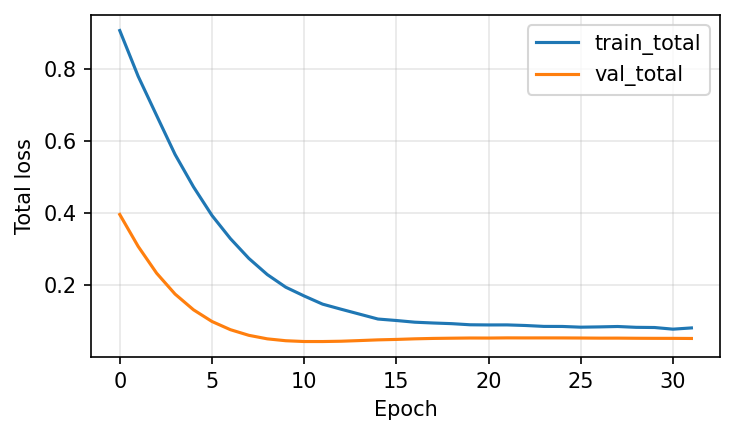

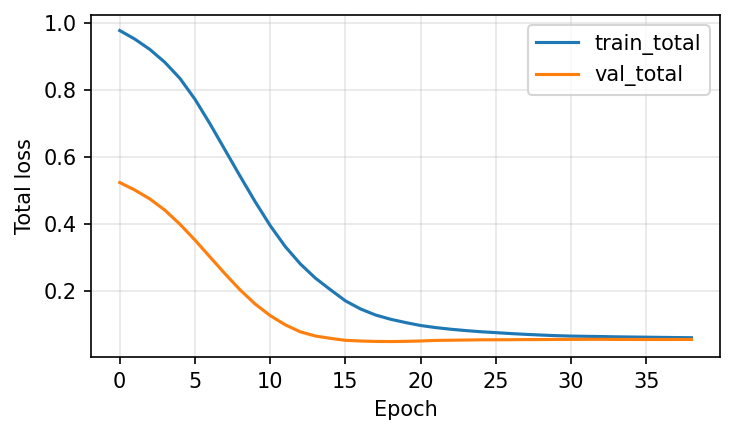

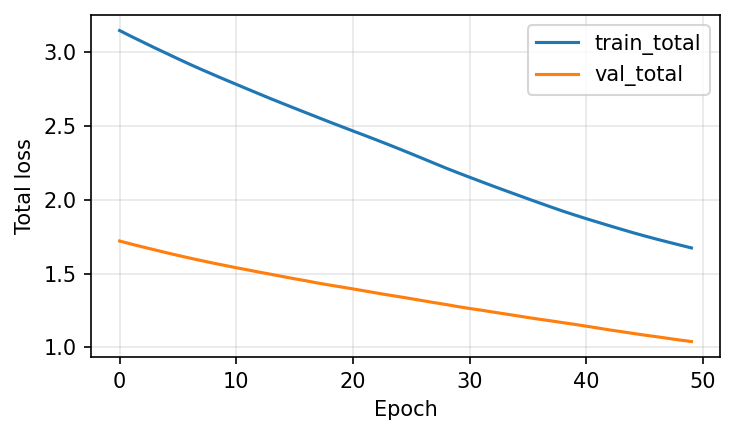

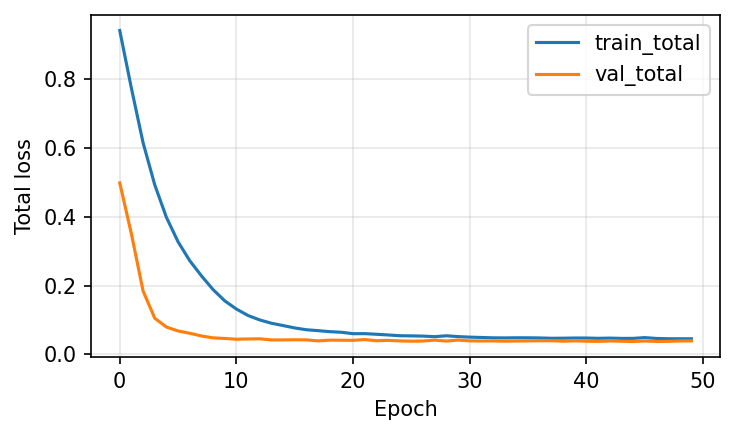

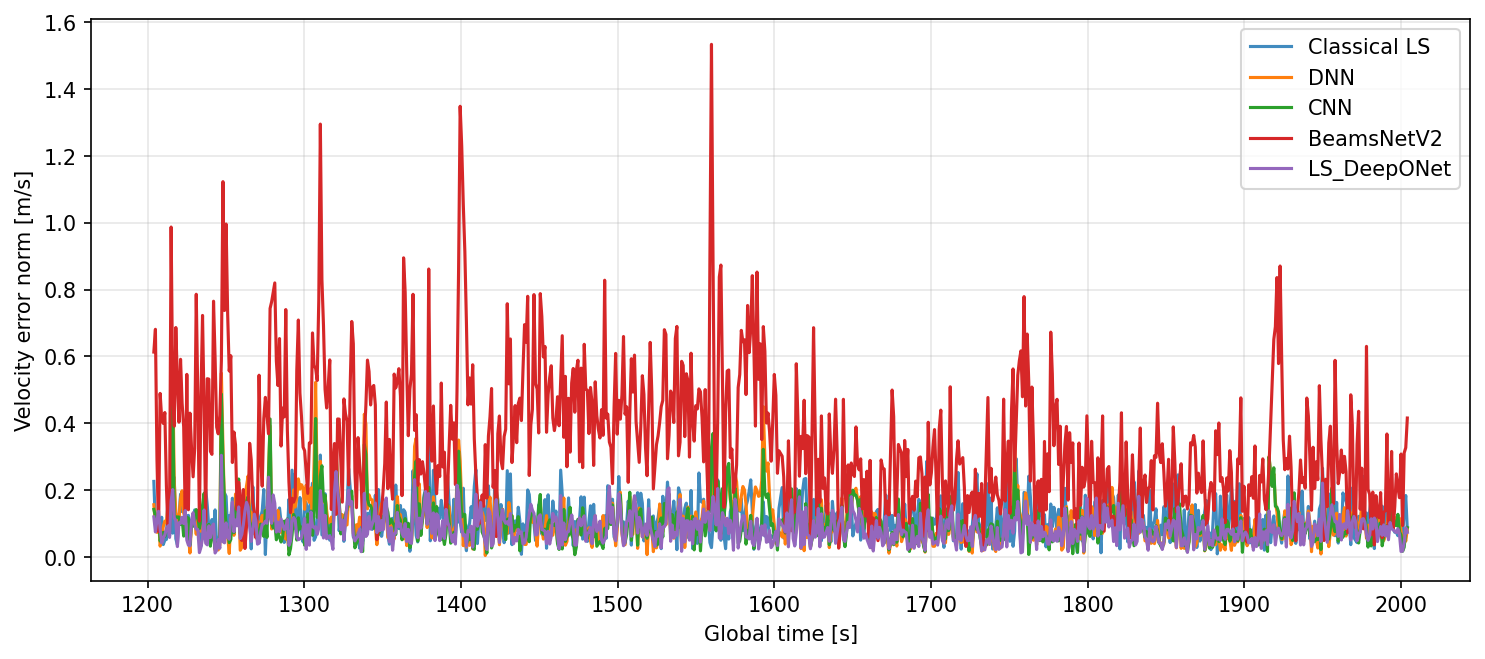

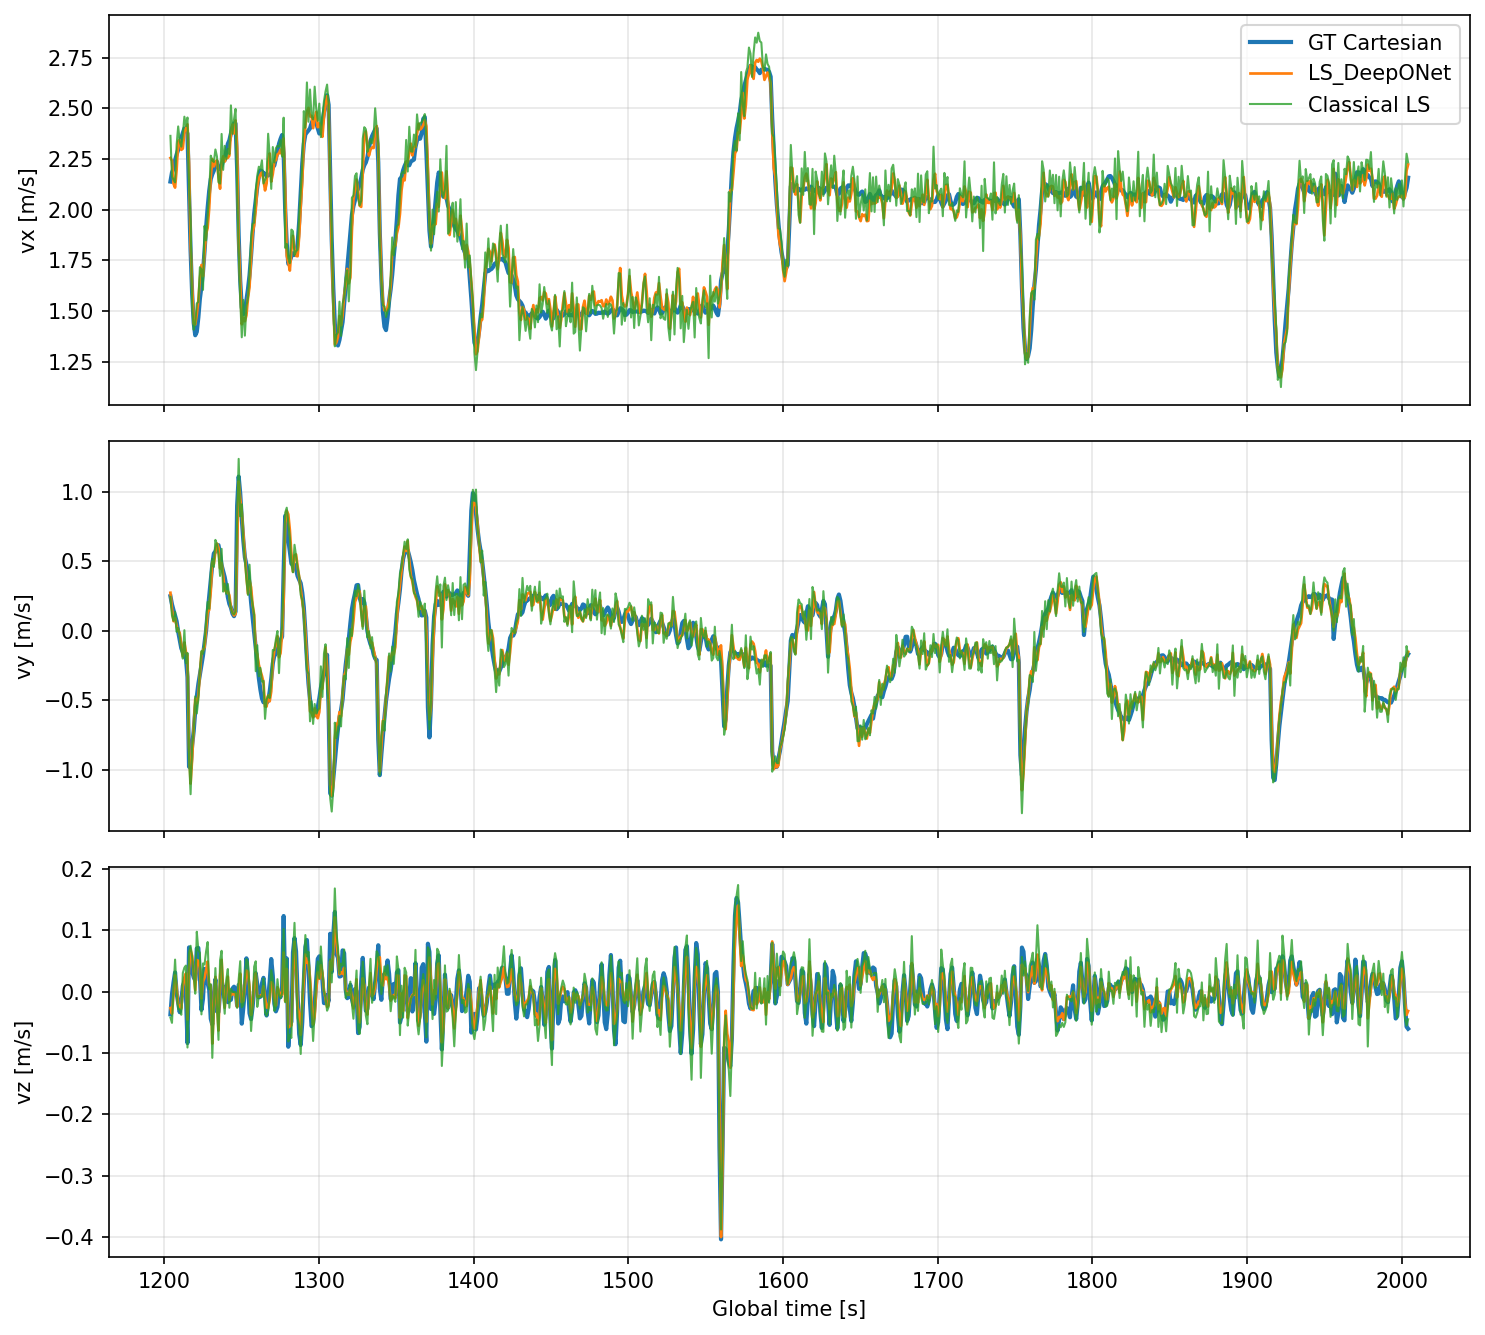

Figures saved in: /home/asahoo/DVL/ls_deeponet_dvl_velocity_results/figures


In [13]:
# ============================================================
# 10. Figures for test split
# ============================================================

axis_names = ["vx", "vy", "vz"][:VEL_DIM]


def plot_loss_for_model(model_name, filename_prefix):
    history = MODEL_RESULTS[model_name]["history"]
    plt.figure(figsize=(5, 3), dpi=150)
    plt.plot(history["train_total"], label="train_total")
    plt.plot(history["val_total"], label="val_total")
    plt.xlabel("Epoch")
    plt.ylabel("Total loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{filename_prefix}_loss_total.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_velocity_error_comparison(split_name="test", filename="velocity_error_time_test_all_models.png"):
    values = split_predictions[split_name]
    t_sec = values["time"]
    gt = values["gt"]

    plt.figure(figsize=(10, 4.5), dpi=150)
    err_ls = np.linalg.norm(values["ls"] - gt, axis=1)
    plt.plot(t_sec, err_ls, label="Classical LS", alpha=0.85)

    for model_name, pred in values["models"].items():
        err = np.linalg.norm(pred - gt, axis=1)
        plt.plot(t_sec, err, label=model_name)

    plt.xlabel("Global time [s]")
    plt.ylabel("Velocity error norm [m/s]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_velocity_components_best(split_name="test", best_model_name="LS_DeepONet", filename="velocity_components_test_best.png"):
    values = split_predictions[split_name]
    t_sec = values["time"]
    gt = values["gt"]
    pred_best = values["models"][best_model_name]
    pred_ls = values["ls"]

    fig, axes = plt.subplots(VEL_DIM, 1, figsize=(10, 3 * VEL_DIM), dpi=150, sharex=True)
    if VEL_DIM == 1:
        axes = [axes]

    for d, ax in enumerate(axes):
        ax.plot(t_sec, gt[:, d], label="GT Cartesian", linewidth=2)
        ax.plot(t_sec, pred_best[:, d], label=best_model_name, linewidth=1.3)
        ax.plot(t_sec, pred_ls[:, d], label="Classical LS", linewidth=1.0, alpha=0.8)
        ax.set_ylabel(f"{axis_names[d]} [m/s]")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Global time [s]")
    axes[0].legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


for model_name in MODEL_NAMES:
    plot_loss_for_model(model_name, model_name.lower())

plot_velocity_error_comparison(split_name="test")
plot_velocity_components_best(split_name="test", best_model_name="LS_DeepONet")

print("Figures saved in:", FIG_DIR.resolve())


In [1]:
# ============================================================
# LS-DeepONet computational complexity and real-time analysis
# ============================================================

import time
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

UPDATE_RATE_HZ = 100.0
AVAILABLE_TIME_MS = 1000.0 / UPDATE_RATE_HZ

WARMUP_RUNS = 100
TIMED_RUNS = 1000


# ------------------------------------------------------------
# Prepare one real test sample
# ------------------------------------------------------------

sample = test_ds[0]

branch_sample = sample["branch"].unsqueeze(0).float().to(DEVICE)
trunk_sample = sample["trunk"].unsqueeze(0).float().to(DEVICE)

print("Branch shape:", tuple(branch_sample.shape))
print("Trunk shape :", tuple(trunk_sample.shape))


# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def synchronize_device():
    if torch.cuda.is_available() and torch.device(DEVICE).type == "cuda":
        torch.cuda.synchronize()


def get_model_file_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix=".pt") as temp_file:
        torch.save(model.state_dict(), temp_file.name)
        size_bytes = Path(temp_file.name).stat().st_size

    return size_bytes / (1024 ** 2)


def get_model_memory_mb(model):
    parameter_bytes = sum(
        p.numel() * p.element_size()
        for p in model.parameters()
    )

    buffer_bytes = sum(
        b.numel() * b.element_size()
        for b in model.buffers()
    )

    return (parameter_bytes + buffer_bytes) / (1024 ** 2)


def calculate_macs_flops(model, branch, trunk):
    """
    Requires THOP.

    Install once if necessary:
        pip install thop
    """

    try:
        from thop import profile

        macs, _ = profile(
            model,
            inputs=(branch, trunk),
            verbose=False,
        )

        flops = 2.0 * macs

        return macs / 1e6, flops / 1e6

    except Exception as error:
        print("MAC/FLOP calculation skipped:", error)
        return np.nan, np.nan


# ------------------------------------------------------------
# Parameter and model-size analysis
# ------------------------------------------------------------

model = model.to(DEVICE)
model.eval()

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

model_file_size_mb = get_model_file_size_mb(model)
model_memory_mb = get_model_memory_mb(model)

macs_million, flops_million = calculate_macs_flops(
    model,
    branch_sample,
    trunk_sample,
)


# ------------------------------------------------------------
# Inference-time analysis
# ------------------------------------------------------------

with torch.inference_mode():

    # Warm-up
    for _ in range(WARMUP_RUNS):
        _ = model(branch_sample, trunk_sample)

synchronize_device()

latencies_ms = []

with torch.inference_mode():

    for _ in range(TIMED_RUNS):

        synchronize_device()
        start_time = time.perf_counter()

        _ = model(branch_sample, trunk_sample)

        synchronize_device()
        end_time = time.perf_counter()

        latencies_ms.append(
            (end_time - start_time) * 1000.0
        )

latencies_ms = np.asarray(latencies_ms)

mean_inference_ms = latencies_ms.mean()
median_inference_ms = np.median(latencies_ms)
p95_inference_ms = np.percentile(latencies_ms, 95)
std_inference_ms = latencies_ms.std(ddof=1)

throughput_samples_per_second = (
    1000.0 / mean_inference_ms
)

real_time_margin = (
    AVAILABLE_TIME_MS / mean_inference_ms
)

real_time_feasible = (
    p95_inference_ms < AVAILABLE_TIME_MS
)


# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------

complexity_table = pd.DataFrame(
    [
        {
            "Model": "LS-DeepONet",
            "Trainable parameters": trainable_parameters,
            "Total parameters": total_parameters,
            "Model file size (MB)": model_file_size_mb,
            "Model memory (MB)": model_memory_mb,
            "MACs (million)": macs_million,
            "FLOPs (million)": flops_million,
            "Mean inference time (ms)": mean_inference_ms,
            "Median inference time (ms)": median_inference_ms,
            "P95 inference time (ms)": p95_inference_ms,
            "Inference std. (ms)": std_inference_ms,
            "Throughput (samples/s)": throughput_samples_per_second,
            "Available time at 100 Hz (ms)": AVAILABLE_TIME_MS,
            "Real-time margin": real_time_margin,
            "Real-time feasible": real_time_feasible,
            "Device": str(DEVICE),
        }
    ]
)

numeric_columns = complexity_table.select_dtypes(
    include=[np.number]
).columns

complexity_table[numeric_columns] = (
    complexity_table[numeric_columns].round(4)
)

display(complexity_table)

complexity_table.to_csv(
    DATA_DIR / "ls_deeponet_complexity_table.csv",
    index=False,
)

complexity_table.to_excel(
    DATA_DIR / "ls_deeponet_complexity_table.xlsx",
    index=False,
)

print("\nSaved:")
print(DATA_DIR / "ls_deeponet_complexity_table.csv")
print(DATA_DIR / "ls_deeponet_complexity_table.xlsx")

## Notes

- If classical LS is already near-perfect, that is expected for synthetic beams generated directly from Cartesian velocity. The neural model is mainly useful when beams are noisy, biased, partially corrupted, or when you want a learned smoother.
- `ALPHA_DEG` must match the beam-generation angle in A-KIT. A wrong angle will make the LS baseline and beam-consistency loss misleading.
- The default split uses whole trajectories for train/validation/test. This is harder and more realistic than randomly splitting samples from every trajectory.
- The model predicts Cartesian velocity only. It does not infer position, attitude, or IMU states.
